<a href="https://colab.research.google.com/github/rosymrd/2025_Pengolahan-Citra_TI2A/blob/main/Jobsheet_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

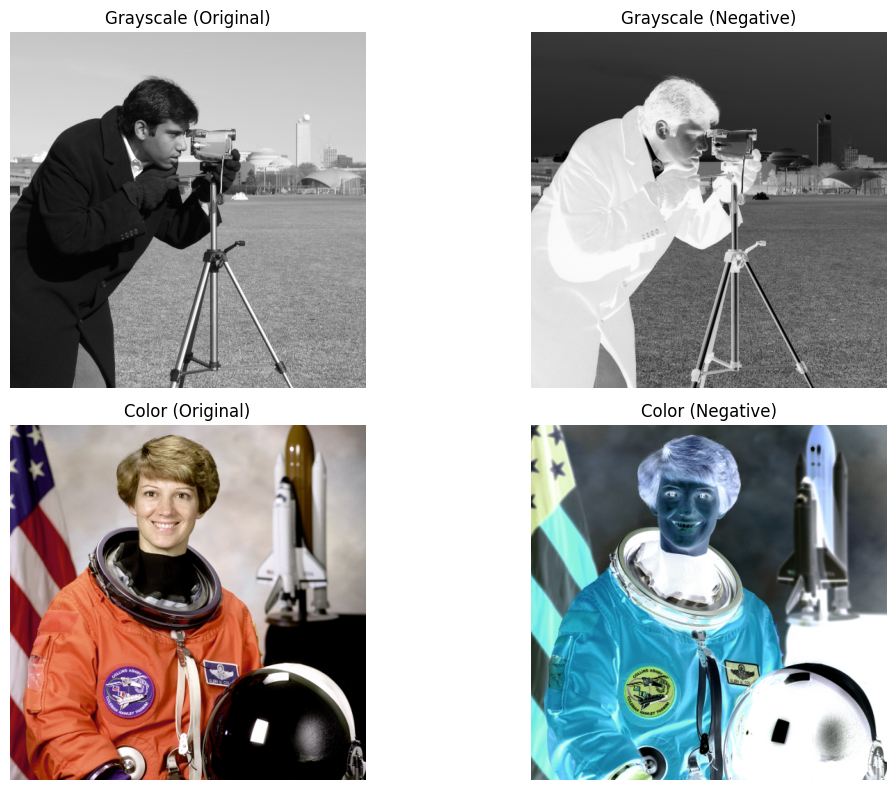

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

# ===================
# 1. TRANSFORMASI NEGATIF CITRA GRAYSCALE
# ===================
image_gray_uint8 = data.camera()                     # Citra grayscale (512x512, 0..255)
image_gray_float = img_as_float(image_gray_uint8)    # Konversi ke float [0..1]
negative_gray = 1.0 - image_gray_float               # Inversi intensitas: output = 1 - input

# ===================
# 2. TRANSFORMASI NEGATIF CITRA BERWARNA
# ===================
image_color_uint8 = data.astronaut()                 # Citra berwarna (512x512x3, 0..255)
image_color_float = img_as_float(image_color_uint8)  # Konversi ke float [0..1]
negative_color = 1.0 - image_color_float             # Inversi intensitas tiap kanal RGB

# ===================
# 3. PLOTTING HASIL
# ===================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Baris 1: Grayscale (original, negative)
axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title("Grayscale (Original)")
axes[0, 0].axis('off')

axes[0, 1].imshow(negative_gray, cmap='gray')
axes[0, 1].set_title("Grayscale (Negative)")
axes[0, 1].axis('off')

# Baris 2: RGB (original, negative)
axes[1, 0].imshow(image_color_float)
axes[1, 0].set_title("Color (Original)")
axes[1, 0].axis('off')

axes[1, 1].imshow(negative_color)
axes[1, 1].set_title("Color (Negative)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


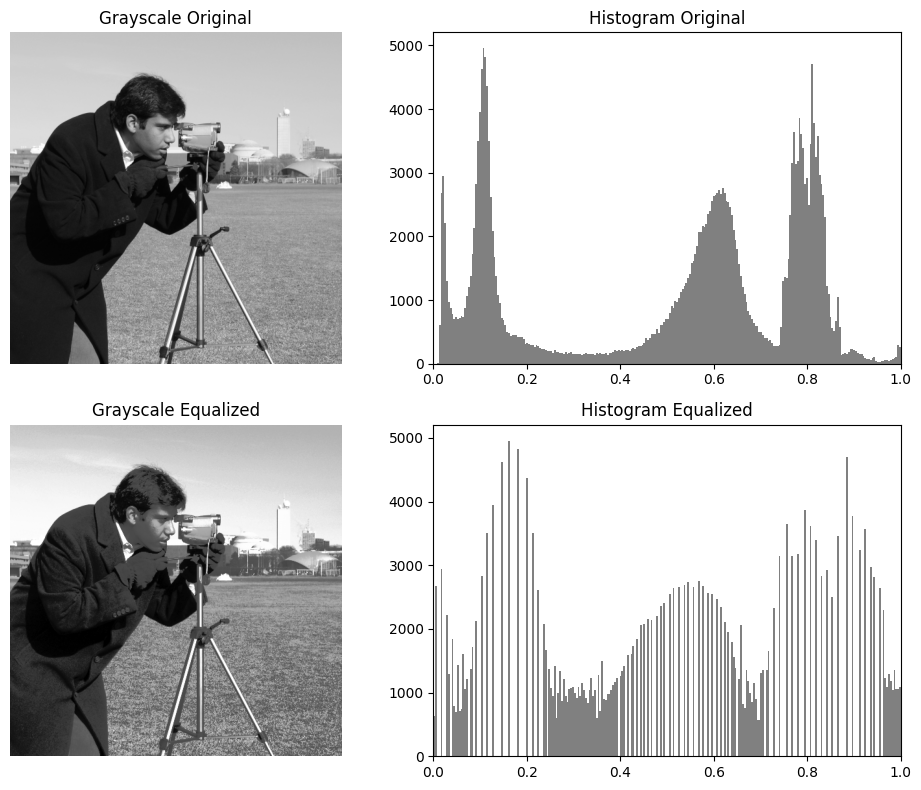

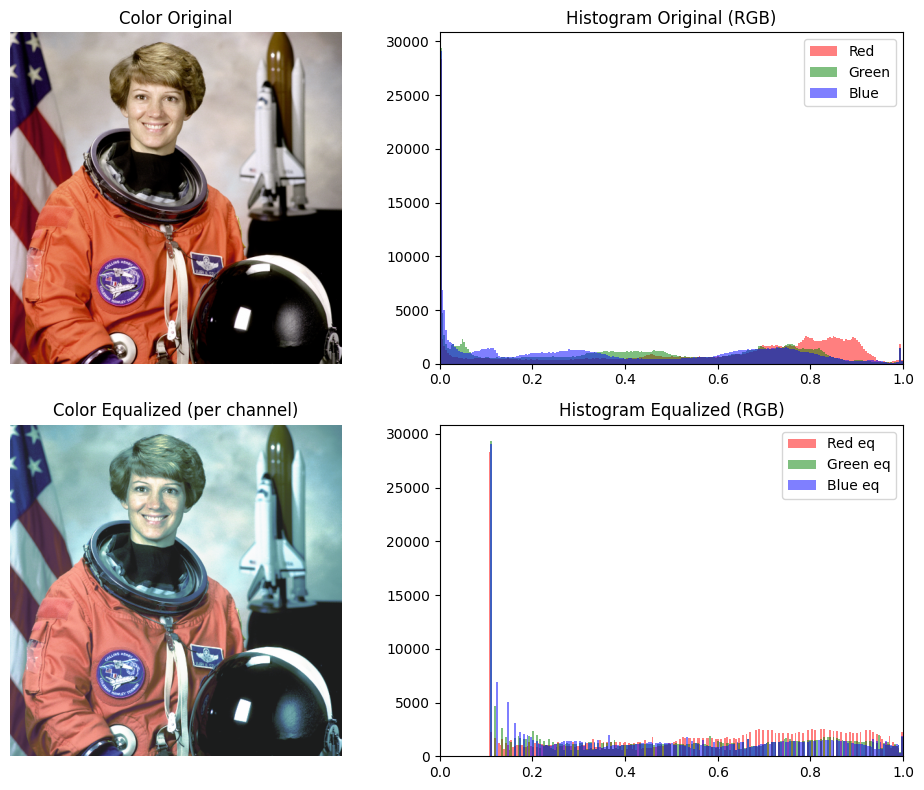

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

# -----------------------------------------------------
# BAGIAN 1: HISTOGRAM & EKUALISASI HISTOGRAM (GRAYSCALE)
# -----------------------------------------------------

# 1. Memuat citra grayscale
image_gray_uint8 = data.camera()  # Citra grayscale (uint8, 0..255)
image_gray = img_as_float(image_gray_uint8)  # Konversi ke float [0..1]

# 2. Menghitung histogram citra asli
hist_gray, bins_gray = np.histogram(image_gray.ravel(), bins=256, range=(0, 1))

# 3. Ekualisasi histogram
image_gray_eq = exposure.equalize_hist(image_gray)
hist_gray_eq, bins_gray_eq = np.histogram(image_gray_eq.ravel(), bins=256, range=(0, 1))

# 4. Plot grayscale: citra & histogram
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra Asli
axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title("Grayscale Original")
axes[0, 0].axis('off')

# (b) Histogram Asli
axes[0, 1].hist(image_gray.ravel(), bins=256, range=(0, 1), color='gray')
axes[0, 1].set_title("Histogram Original")
axes[0, 1].set_xlim(0, 1)

# (c) Citra Ekualisasi
axes[1, 0].imshow(image_gray_eq, cmap='gray')
axes[1, 0].set_title("Grayscale Equalized")
axes[1, 0].axis('off')

# (d) Histogram Ekualisasi
axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0, 1), color='gray')
axes[1, 1].set_title("Histogram Equalized")
axes[1, 1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# BAGIAN 2: HISTOGRAM & EKUALISASI HISTOGRAM (CITRA WARNA)
# -------------------------------------------------------

# 1. Memuat citra berwarna
image_color_uint8 = data.astronaut()  # RGB (uint8)
image_color = img_as_float(image_color_uint8)  # Konversi ke float [0..1]

# 2. Pisahkan kanal R, G, B
r_channel = image_color[:, :, 0]
g_channel = image_color[:, :, 1]
b_channel = image_color[:, :, 2]

# Hitung histogram masing-masing kanal
hist_r, bins_r = np.histogram(r_channel.ravel(), bins=256, range=(0, 1))
hist_g, bins_g = np.histogram(g_channel.ravel(), bins=256, range=(0, 1))
hist_b, bins_b = np.histogram(b_channel.ravel(), bins=256, range=(0, 1))

# 3. Ekualisasi histogram tiap kanal
r_eq = exposure.equalize_hist(r_channel)
g_eq = exposure.equalize_hist(g_channel)
b_eq = exposure.equalize_hist(b_channel)

# Gabungkan kanal menjadi RGB kembali
image_color_eq = np.dstack((r_eq, g_eq, b_eq))

# Hitung histogram hasil ekualisasi
hist_r_eq, bins_r_eq = np.histogram(r_eq.ravel(), bins=256, range=(0, 1))
hist_g_eq, bins_g_eq = np.histogram(g_eq.ravel(), bins=256, range=(0, 1))
hist_b_eq, bins_b_eq = np.histogram(b_eq.ravel(), bins=256, range=(0, 1))

# 4. Plot citra berwarna & histogram
fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra Asli
axes2[0, 0].imshow(image_color)
axes2[0, 0].set_title("Color Original")
axes2[0, 0].axis('off')

# (b) Histogram Asli (RGB)
axes2[0, 1].hist(r_channel.ravel(), bins=256, range=(0, 1), color='red', alpha=0.5, label='Red')
axes2[0, 1].hist(g_channel.ravel(), bins=256, range=(0, 1), color='green', alpha=0.5, label='Green')
axes2[0, 1].hist(b_channel.ravel(), bins=256, range=(0, 1), color='blue', alpha=0.5, label='Blue')
axes2[0, 1].set_title("Histogram Original (RGB)")
axes2[0, 1].set_xlim(0, 1)
axes2[0, 1].legend(loc='upper right')

# (c) Citra Ekualisasi
axes2[1, 0].imshow(image_color_eq)
axes2[1, 0].set_title("Color Equalized (per channel)")
axes2[1, 0].axis('off')

# (d) Histogram Ekualisasi (RGB)
axes2[1, 1].hist(r_eq.ravel(), bins=256, range=(0, 1), color='red', alpha=0.5, label='Red eq')
axes2[1, 1].hist(g_eq.ravel(), bins=256, range=(0, 1), color='green', alpha=0.5, label='Green eq')
axes2[1, 1].hist(b_eq.ravel(), bins=256, range=(0, 1), color='blue', alpha=0.5, label='Blue eq')
axes2[1, 1].set_title("Histogram Equalized (RGB)")
axes2[1, 1].set_xlim(0, 1)
axes2[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()


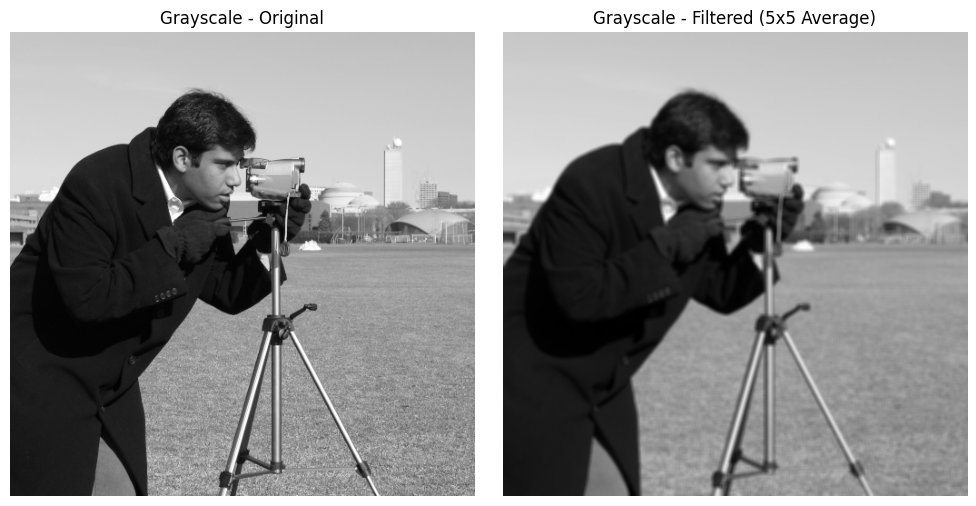

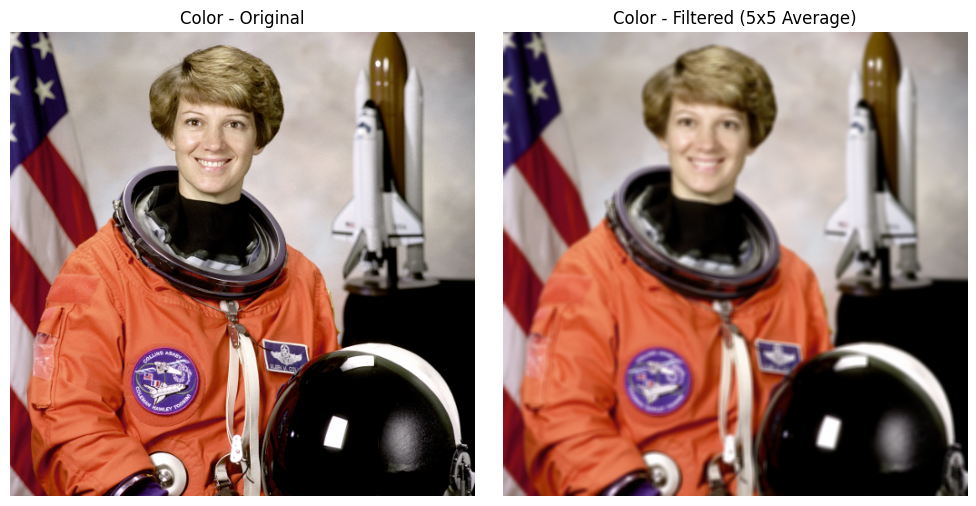

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy import ndimage as ndi

# --------------------------------------------------
# 1) FILTER RATA-RATA PADA CITRA GRAYSCALE
# --------------------------------------------------

# A. Memuat citra grayscale (camera)
gray_uint8 = data.camera()  # range 0..255
gray_img = img_as_float(gray_uint8)  # konversi menjadi float [0..1] untuk kemudahan

# B. Definisikan kernel filter rata-rata (contoh: 5x5)
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size * kernel_size)

# C. Lakukan konvolusi pada citra grayscale
gray_filtered = ndi.convolve(gray_img, kernel, mode='reflect')

# D. Tampilkan hasil
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_filtered, cmap='gray')
axes[1].set_title(f"Grayscale - Filtered ({kernel_size}x{kernel_size} Average)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2) FILTER RATA-RATA PADA CITRA BERWARNA
# --------------------------------------------------

# A. Memuat citra berwarna (astronaut)
color_uint8 = data.astronaut()  # citra RGB (uint8, 0..255)
color_img = img_as_float(color_uint8)  # konversi float [0..1]

# B. Terapkan filter rata-rata pada tiap kanal R, G, B
color_filtered = np.zeros_like(color_img)

for c in range(3):  # c = 0 (Red), 1 (Green), 2 (Blue)
    channel_original = color_img[:, :, c]
    channel_filtered = ndi.convolve(channel_original, kernel, mode='reflect')
    color_filtered[:, :, c] = channel_filtered

# C. Tampilkan hasil
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))
axes2[0].imshow(color_img)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_filtered)
axes2[1].set_title(f"Color - Filtered ({kernel_size}x{kernel_size} Average)")
axes2[1].axis('off')

plt.tight_layout()
plt.show()


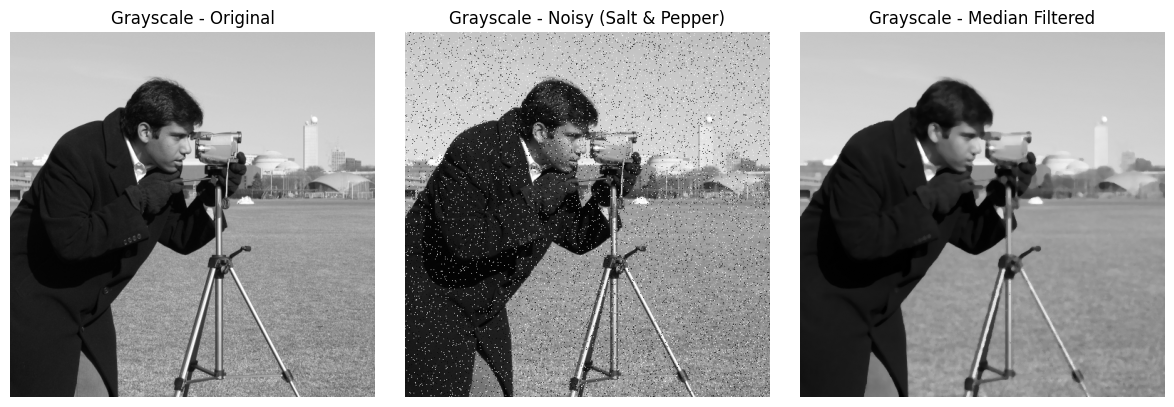

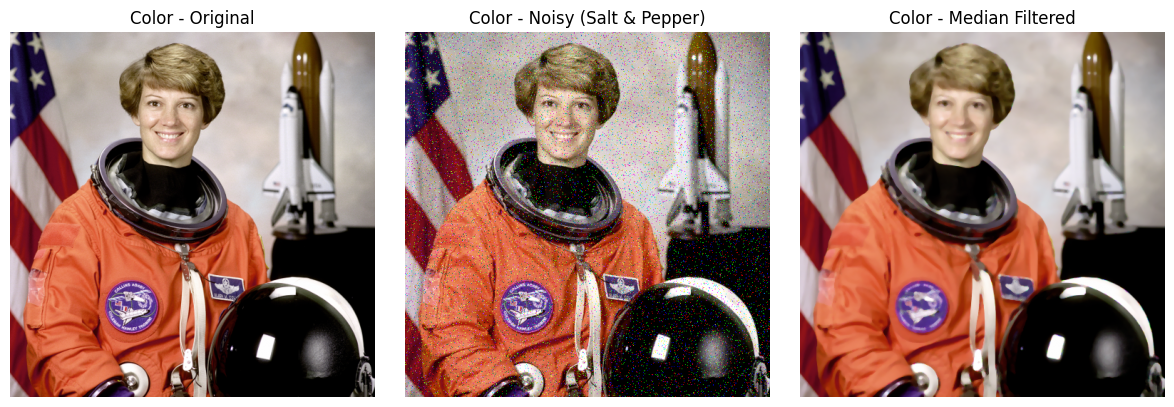

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, morphology, img_as_float

# -----------------------------------------
# 1) FILTER MEDIAN PADA CITRA GRAYSCALE
# -----------------------------------------

# A. Memuat citra grayscale
gray_uint8 = data.camera()    # grayscale, uint8
gray_float = img_as_float(gray_uint8)  # konversi ke float [0..1]

# B. Menambahkan noise jenis salt-and-pepper
gray_noisy = util.random_noise(gray_float, mode='s&p', amount=0.05)  # 5% noise

# C. Menerapkan filter median dengan disk radius 3
disk3 = morphology.disk(3)
gray_denoised = filters.median(gray_noisy, disk3)

# D. Tampilkan hasil
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray_float, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_noisy, cmap='gray')
axes[1].set_title("Grayscale - Noisy (Salt & Pepper)")
axes[1].axis('off')

axes[2].imshow(gray_denoised, cmap='gray')
axes[2].set_title("Grayscale - Median Filtered")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# -----------------------------------------
# 2) FILTER MEDIAN PADA CITRA BERWARNA
# -----------------------------------------

# A. Memuat citra berwarna (RGB)
color_uint8 = data.astronaut()     # RGB, uint8
color_float = img_as_float(color_uint8)  # konversi ke float [0..1]

# B. Menambahkan noise salt-and-pepper
color_noisy = util.random_noise(color_float, mode='s&p', amount=0.05)

# C. Menerapkan filter median pada tiap channel RGB
color_denoised = np.zeros_like(color_noisy)
for c in range(3):  # 0: Red, 1: Green, 2: Blue
    color_denoised[:, :, c] = filters.median(color_noisy[:, :, c], morphology.disk(3))

# D. Tampilkan hasil
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
axes2[0].imshow(color_float)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_noisy)
axes2[1].set_title("Color - Noisy (Salt & Pepper)")
axes2[1].axis('off')

axes2[2].imshow(color_denoised)
axes2[2].set_title("Color - Median Filtered")
axes2[2].axis('off')

plt.tight_layout()
plt.show()


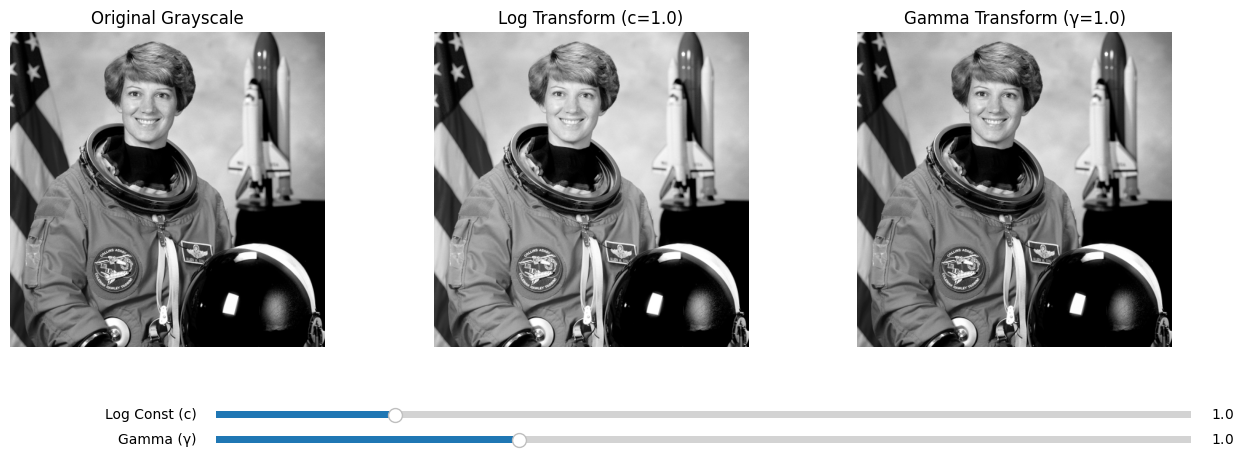

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from skimage import data, color, exposure, img_as_float

# A. Load citra dan konversi ke grayscale & float
img = img_as_float(color.rgb2gray(data.astronaut()))

# B. Fungsi transformasi
def log_transform(image, c):
    return c * np.log1p(image)

def update(val):
    gamma = gamma_slider.val
    c = c_slider.val

    log_img = log_transform(img, c)
    gamma_img = exposure.adjust_gamma(img, gamma)

    ax2.imshow(log_img, cmap='gray')
    ax2.set_title(f'Log Transform (c={c:.2f})')

    ax3.imshow(gamma_img, cmap='gray')
    ax3.set_title(f'Gamma Transform (γ={gamma:.2f})')

    fig.canvas.draw_idle()

# C. Buat plot awal
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
plt.subplots_adjust(left=0.1, bottom=0.25)

ax1.imshow(img, cmap='gray')
ax1.set_title('Original Grayscale')
ax1.axis('off')

# Dummy awal
log_img = log_transform(img, 1.0)
gamma_img = exposure.adjust_gamma(img, 1.0)

ax2.imshow(log_img, cmap='gray')
ax2.set_title('Log Transform (c=1.0)')
ax2.axis('off')

ax3.imshow(gamma_img, cmap='gray')
ax3.set_title('Gamma Transform (γ=1.0)')
ax3.axis('off')

# D. Slider
ax_c = plt.axes([0.25, 0.1, 0.65, 0.03])
ax_gamma = plt.axes([0.25, 0.05, 0.65, 0.03])

c_slider = Slider(ax_c, 'Log Const (c)', 0.1, 5.0, valinit=1.0)
gamma_slider = Slider(ax_gamma, 'Gamma (γ)', 0.1, 3.0, valinit=1.0)

c_slider.on_changed(update)
gamma_slider.on_changed(update)

plt.show()


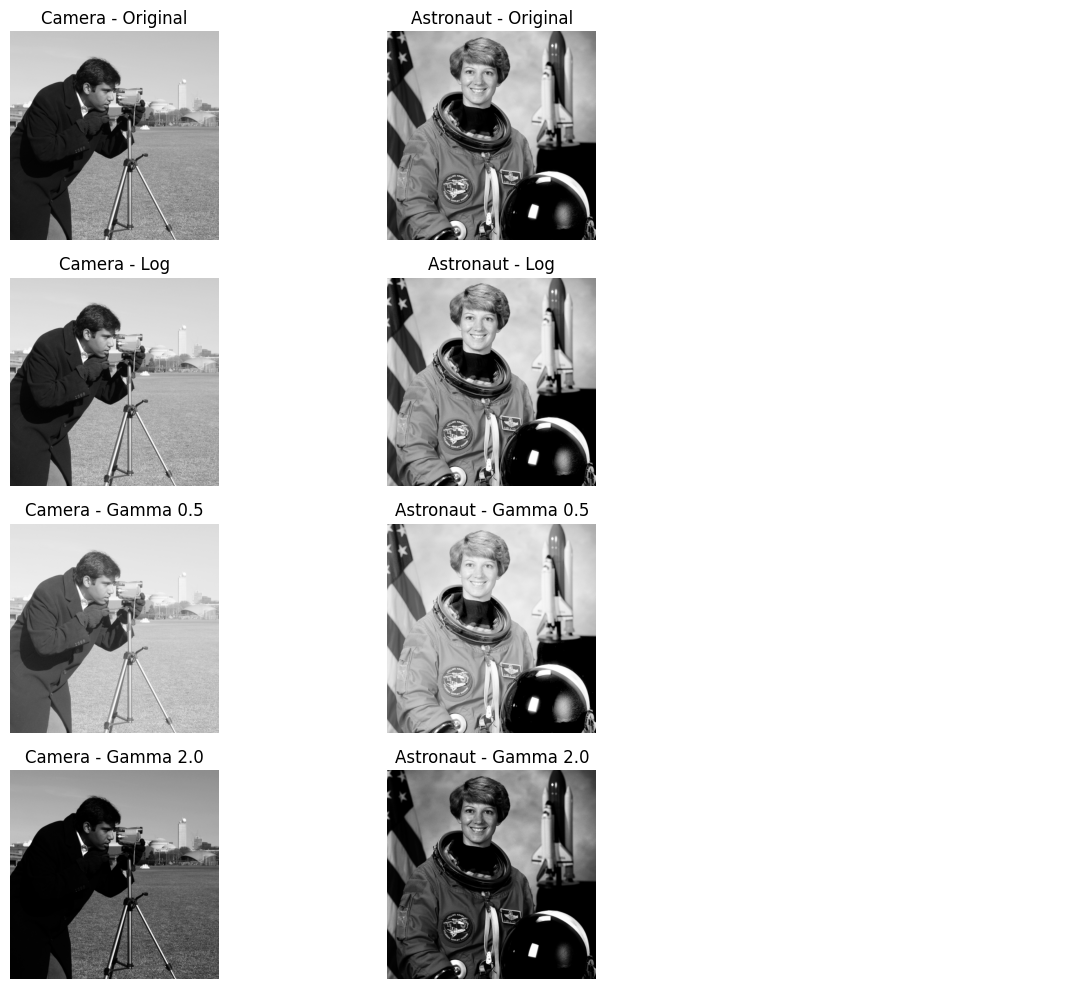

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, exposure, img_as_float

# load gambar camera (grayscale) dan astronaut (RGB ke grayscale)
img1 = img_as_float(data.camera())
img2 = img_as_float(color.rgb2gray(data.astronaut()))

# transformasi logaritmik
def log_transform(img, c=1):
    return c * np.log1p(img)

log1 = log_transform(img1, c=1)
log2 = log_transform(img2, c=1)

# transformasi gamma
g_low = 0.5
g_high = 2.0

gamma1_low = exposure.adjust_gamma(img1, gamma=g_low)
gamma1_high = exposure.adjust_gamma(img1, gamma=g_high)

gamma2_low = exposure.adjust_gamma(img2, gamma=g_low)
gamma2_high = exposure.adjust_gamma(img2, gamma=g_high)

# plotting semua hasil
fig, ax = plt.subplots(4, 3, figsize=(12, 10))

# baris 1 - original
ax[0,0].imshow(img1, cmap='gray'); ax[0,0].set_title('Camera - Original')
ax[0,1].imshow(img2, cmap='gray'); ax[0,1].set_title('Astronaut - Original')
ax[0,2].axis('off')

# baris 2 - log
ax[1,0].imshow(log1, cmap='gray'); ax[1,0].set_title('Camera - Log')
ax[1,1].imshow(log2, cmap='gray'); ax[1,1].set_title('Astronaut - Log')
ax[1,2].axis('off')

# baris 3 - gamma < 1 (cerah)
ax[2,0].imshow(gamma1_low, cmap='gray'); ax[2,0].set_title('Camera - Gamma 0.5')
ax[2,1].imshow(gamma2_low, cmap='gray'); ax[2,1].set_title('Astronaut - Gamma 0.5')
ax[2,2].axis('off')

# baris 4 - gamma > 1 (gelap)
ax[3,0].imshow(gamma1_high, cmap='gray'); ax[3,0].set_title('Camera - Gamma 2.0')
ax[3,1].imshow(gamma2_high, cmap='gray'); ax[3,1].set_title('Astronaut - Gamma 2.0')
ax[3,2].axis('off')

# bersihkan axis dan tampilkan
for a in ax.ravel(): a.axis('off')
plt.tight_layout()
plt.show()


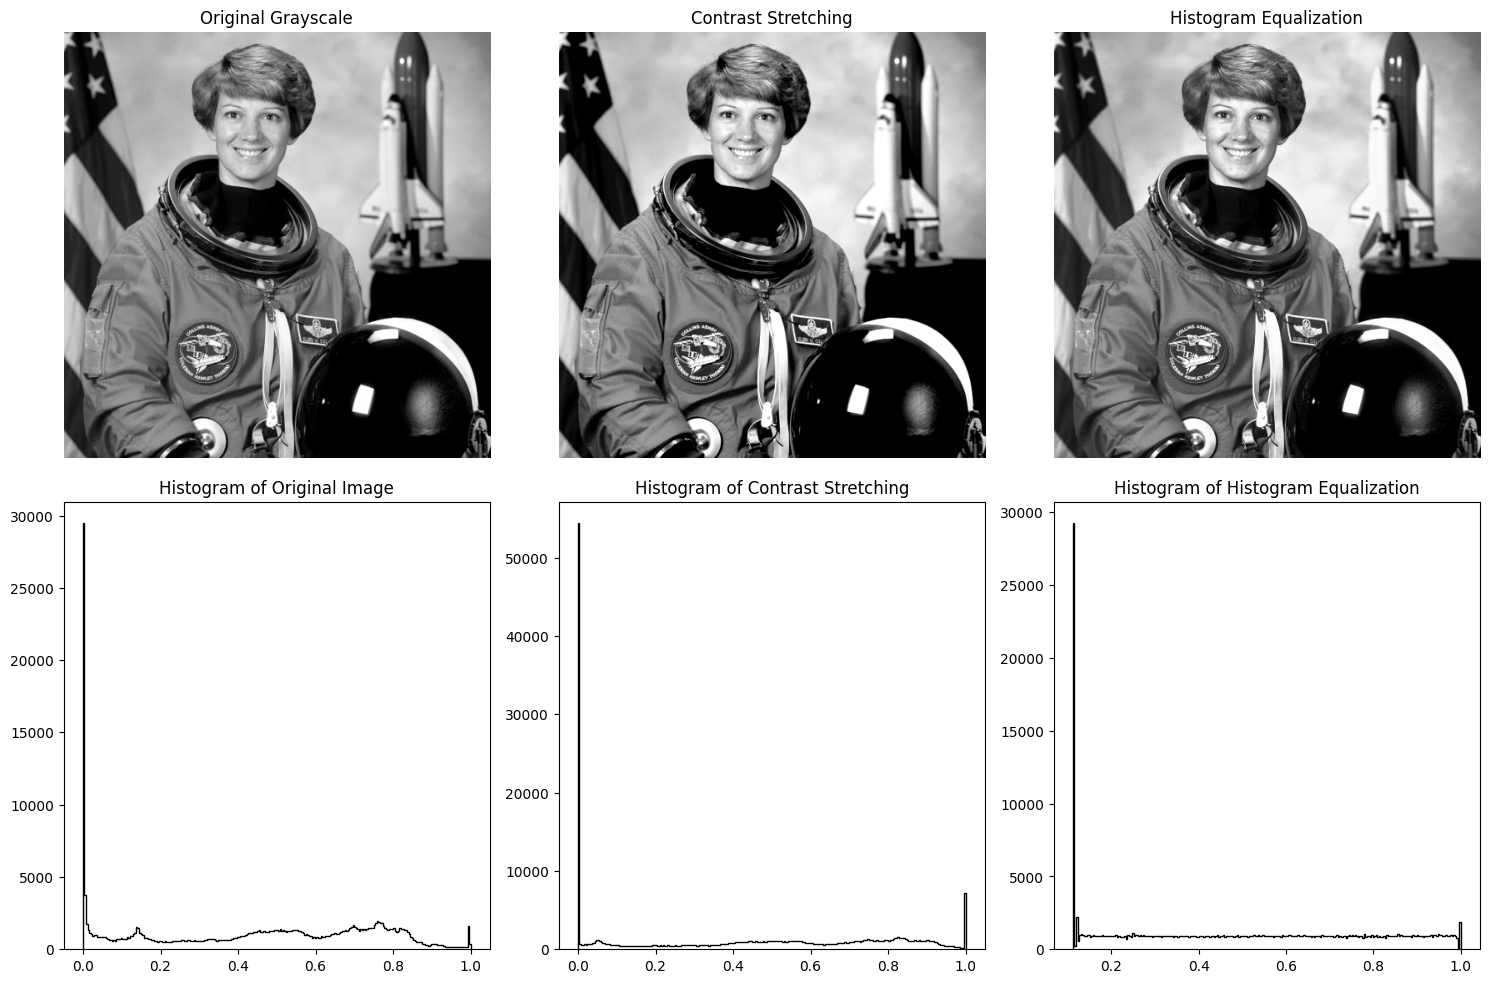

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, exposure, img_as_float

# A. Load citra dan konversi ke grayscale & float
img = img_as_float(color.rgb2gray(data.astronaut()))

# B. Terapkan contrast stretching menggunakan exposure.rescale_intensity
contrast_stretched_img = exposure.rescale_intensity(img, in_range=(0.1, 0.9))

# C. Terapkan histogram equalization menggunakan exposure.equalize_hist
equalized_img = exposure.equalize_hist(img)

# D. Buat plot untuk menampilkan hasil citra dan histogram
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Citra asli
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original Grayscale')
axes[0, 0].axis('off')

# Citra dengan contrast stretching
axes[0, 1].imshow(contrast_stretched_img, cmap='gray')
axes[0, 1].set_title('Contrast Stretching')
axes[0, 1].axis('off')

# Citra dengan histogram equalization
axes[0, 2].imshow(equalized_img, cmap='gray')
axes[0, 2].set_title('Histogram Equalization')
axes[0, 2].axis('off')

# Histogram asli
axes[1, 0].hist(img.ravel(), bins=256, histtype='step', color='black')
axes[1, 0].set_title('Histogram of Original Image')

# Histogram setelah contrast stretching
axes[1, 1].hist(contrast_stretched_img.ravel(), bins=256, histtype='step', color='black')
axes[1, 1].set_title('Histogram of Contrast Stretching')

# Histogram setelah histogram equalization
axes[1, 2].hist(equalized_img.ravel(), bins=256, histtype='step', color='black')
axes[1, 2].set_title('Histogram of Histogram Equalization')

plt.tight_layout()
plt.show()


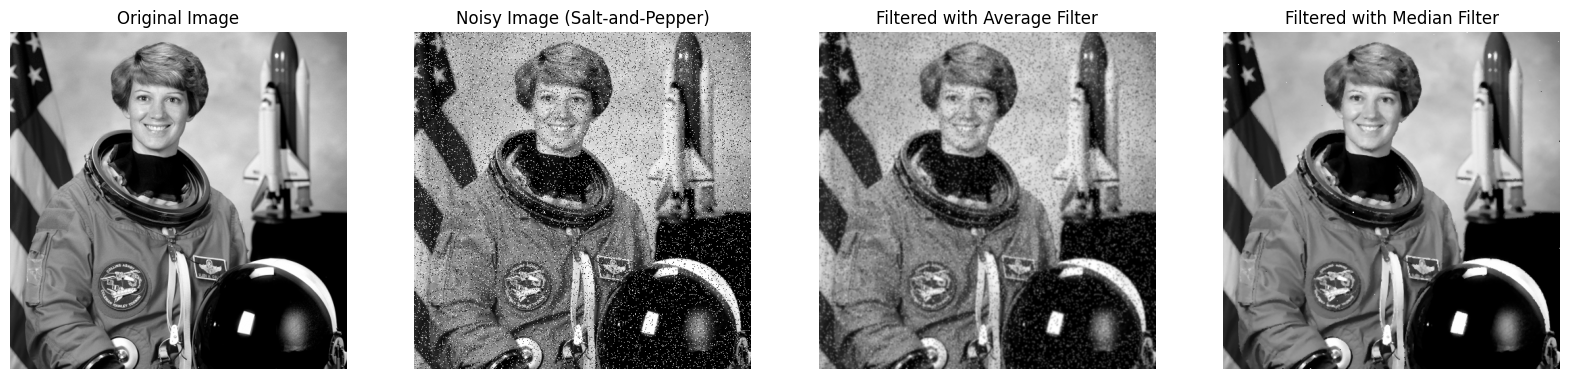

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters
from skimage import color

# A. Muat citra dan konversi ke grayscale
img = color.rgb2gray(data.astronaut())

# B. Tambahkan noise salt-and-pepper pada citra
noisy_img = util.random_noise(img, mode='s&p', amount=0.1)

# C. Terapkan filter rata-rata
average_filter = filters.gaussian(noisy_img, sigma=1)  # Bisa juga menggunakan konvolusi kernel ones

# D. Terapkan filter median
median_filter = filters.median(noisy_img)

# E. Tampilkan citra asli, citra berderau, dan hasil filter
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
ax1, ax2, ax3, ax4 = axes

ax1.imshow(img, cmap='gray')
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(noisy_img, cmap='gray')
ax2.set_title('Noisy Image (Salt-and-Pepper)')
ax2.axis('off')

ax3.imshow(average_filter, cmap='gray')
ax3.set_title('Filtered with Average Filter')
ax3.axis('off')

ax4.imshow(median_filter, cmap='gray')
ax4.set_title('Filtered with Median Filter')
ax4.axis('off')

plt.show()
